In [1]:
import datajoint as dj

/Users/ct5868/code/U19-pipeline-python.worktrees/main/.venv/lib/python3.13/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # requires setuptools<82


In [2]:
action = dj.create_virtual_module('action', 'u19_action')


[2026-06-10 15:26:14,811][INFO]: DataJoint 0.14.9 connected to u19tech@datajoint00.pni.princeton.edu:3306


In [3]:
startup_times = action.RigStartupTime().fetch(format='frame')


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# --- Deduplicate: within each location, if two startups are within 45s, keep the older one ---
df = startup_times.reset_index().copy()
df['startup_datetime'] = pd.to_datetime(df['startup_datetime'])
df = df.sort_values(['location', 'startup_datetime'])

def drop_close_duplicates(group, threshold_sec=45):
    group = group.sort_values('startup_datetime').reset_index(drop=True)
    keep = [True]
    for i in range(1, len(group)):
        delta = (group.loc[i, 'startup_datetime'] - group.loc[i-1, 'startup_datetime']).total_seconds()
        keep.append(delta > threshold_sec)
    return group[keep]

df_clean = (
    df.groupby('location', group_keys=True)
    .apply(drop_close_duplicates)
    .reset_index(drop=False)
)
df_clean['startup_time'] = pd.to_numeric(df_clean['startup_time'], errors='coerce')
df_clean['num_subj_scheduled'] = pd.to_numeric(df_clean['num_subj_scheduled'], errors='coerce')

# Remove rows with startup_time > 5000s
n_before = len(df_clean)
df_clean = df_clean[df_clean['startup_time'] <= 5000].copy()
print(f"Raw rows: {len(df)}, after dedup: {n_before}, after removing >5000s: {len(df_clean)} ({n_before - len(df_clean)} dropped)")
df_clean.head()


Raw rows: 4020, after dedup: 3554, after removing >5000s: 3553 (1 dropped)


,location,level_1,startup_datetime,startup_type,num_subj_scheduled,startup_time
0,165A-WeightGUI,0,2026-04-26 20:38:05,Not using New Training GUI,0,0.757197
1,165A-WeightGUI,1,2026-04-27 08:38:16,Not using New Training GUI,0,11.239300
2,165A-WeightGUI,2,2026-04-28 08:37:08,Not using New Training GUI,0,17.046200
3,165A-WeightGUI,3,2026-04-29 09:21:40,Not using New Training GUI,0,17.444300
4,165A-WeightGUI,4,2026-04-29 21:00:39,Not using New Training GUI,0,6.142370


                     median       mean        std  count        p90
location                                                           
165I-Rig1-T       32.098200  32.465262   4.057086    379  36.486360
165I-Rig3-T       28.126900  27.285213   5.383005    243  33.770480
165I-Rig4-T       25.861500  28.251202   4.741532    287  35.431620
165I-Rig2-T       20.470900  22.090210   5.255666    242  29.857100
165A-miniVR-T-3   19.374400  27.616695  13.690645    153  48.535580
165A-miniVR-T-1   17.574400  25.381369  15.197380    164  51.337100
165A-WeightGUI    16.471300  16.278955   5.735580     55  21.830620
165A-miniVR-T-2   15.542400  22.344808  13.073294    191  43.950700
165A-miniVR-T-6   15.032800  19.596601   7.452804    345  28.108140
165A-miniVR-T-4   14.302200  18.403323   6.478309    275  27.618300
165A-miniVR-T-5   13.158500  17.795140   6.804580    347  29.239740
185F-Rig1         11.246600  10.144367   4.131079     10  14.077210
165A-miniVR-T-9   10.213250  12.185063   4.63514

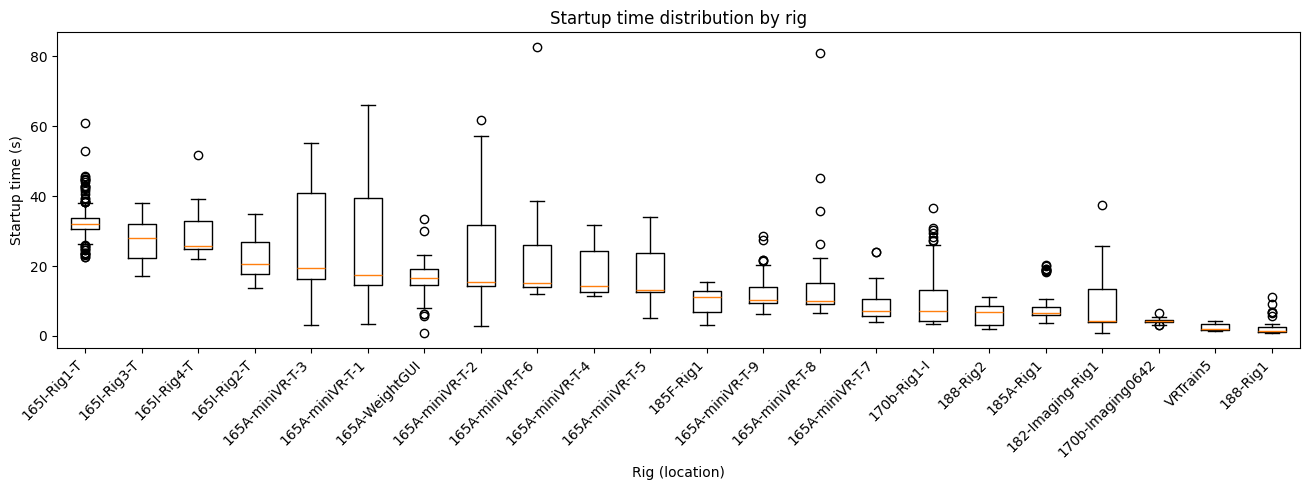

In [5]:
# --- Startup time by rig (location) ---
rig_stats = (
    df_clean.groupby('location')['startup_time']
    .agg(median='median', mean='mean', std='std', count='count', p90=lambda x: x.quantile(0.9))
    .sort_values('median', ascending=False)
)
print(rig_stats.to_string())

fig, ax = plt.subplots(figsize=(max(8, len(rig_stats) * 0.6), 5))
order = rig_stats.index.tolist()
data_by_rig = [df_clean[df_clean['location'] == loc]['startup_time'].dropna() for loc in order]
ax.boxplot(data_by_rig, tick_labels=order, vert=True)
ax.set_xlabel('Rig (location)')
ax.set_ylabel('Startup time (s)')
ax.set_title('Startup time distribution by rig')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


                               median       mean       std  count       p90
startup_type                                                               
Rig Tester                  31.238500  31.837000  9.715271    561  46.66740
Training Flow GUI           20.050300  21.549384  8.359536   2193  32.82720
No Schedule                  9.039780   9.020534  3.262082    231  12.29340
Not using New Training GUI   4.701765   7.631156  6.474423    568  18.23323


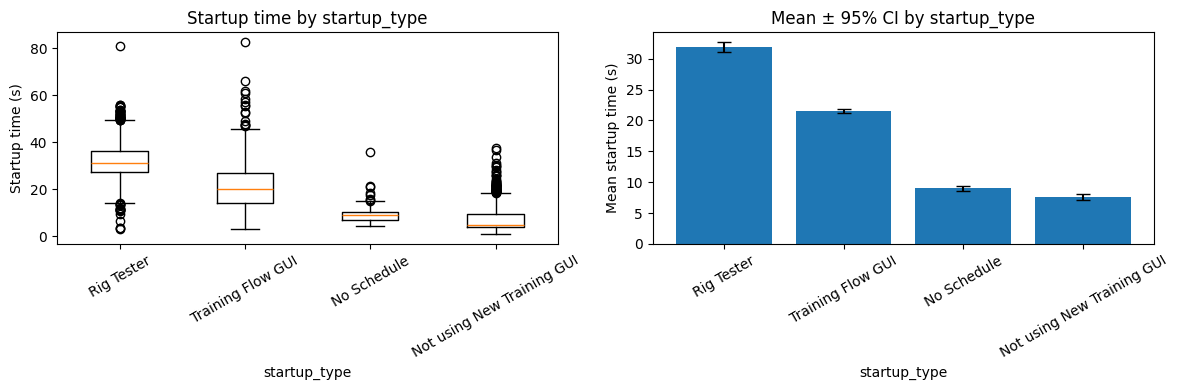

In [6]:
# --- Startup time by startup_type ---
type_stats = (
    df_clean.groupby('startup_type')['startup_time']
    .agg(median='median', mean='mean', std='std', count='count', p90=lambda x: x.quantile(0.9))
    .sort_values('median', ascending=False)
)
print(type_stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot by startup_type
order_t = type_stats.index.tolist()
axes[0].boxplot(
    [df_clean[df_clean['startup_type'] == t]['startup_time'].dropna() for t in order_t],
    tick_labels=order_t,
)
axes[0].set_xlabel('startup_type')
axes[0].set_ylabel('Startup time (s)')
axes[0].set_title('Startup time by startup_type')
axes[0].tick_params(axis='x', rotation=30)

# Mean + 95% CI bar chart
means = type_stats['mean']
sems = df_clean.groupby('startup_type')['startup_time'].sem()
axes[1].bar(order_t, means[order_t], yerr=1.96 * sems[order_t], capsize=5)
axes[1].set_xlabel('startup_type')
axes[1].set_ylabel('Mean startup time (s)')
axes[1].set_title('Mean ± 95% CI by startup_type')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


Pearson r(num_subj_scheduled, startup_time) = 0.412
 num_subj_scheduled   median      mean  count
                  0  6.61610  8.032841    799
                  1 25.50250 26.170074     97
                  2 16.98010 22.656188    537
                  3 23.23835 25.348301    488
                  4 24.97985 24.995664    536
                  5 26.14480 25.305689    391
                  6 21.98200 20.923852    705


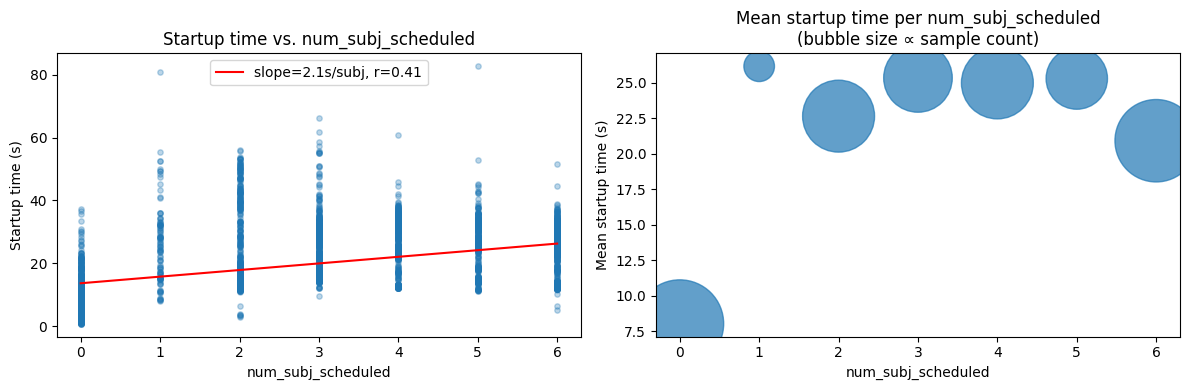

In [7]:
# --- Effect of num_subj_scheduled on startup_time ---
corr = df_clean[['num_subj_scheduled', 'startup_time']].corr().iloc[0, 1]
print(f"Pearson r(num_subj_scheduled, startup_time) = {corr:.3f}")

subj_stats = (
    df_clean.groupby('num_subj_scheduled')['startup_time']
    .agg(median='median', mean='mean', count='count')
    .reset_index()
    .sort_values('num_subj_scheduled')
)
print(subj_stats.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter with regression line
x = df_clean['num_subj_scheduled'].dropna()
y = df_clean.loc[x.index, 'startup_time']
m, b = np.polyfit(x, y, 1)
axes[0].scatter(x, y, alpha=0.3, s=15)
xs = np.linspace(x.min(), x.max(), 100)
axes[0].plot(xs, m * xs + b, 'r-', label=f'slope={m:.1f}s/subj, r={corr:.2f}')
axes[0].set_xlabel('num_subj_scheduled')
axes[0].set_ylabel('Startup time (s)')
axes[0].set_title('Startup time vs. num_subj_scheduled')
axes[0].legend()

# Mean startup time per num_subj_scheduled (size ∝ count)
sc = axes[1].scatter(
    subj_stats['num_subj_scheduled'], subj_stats['mean'],
    s=subj_stats['count'] * 5, alpha=0.7,
)
axes[1].set_xlabel('num_subj_scheduled')
axes[1].set_ylabel('Mean startup time (s)')
axes[1].set_title('Mean startup time per num_subj_scheduled\n(bubble size ∝ sample count)')

plt.tight_layout()
plt.show()


In [8]:
# --- Filter to "good data" (after May 15th) ---
cutoff_date = pd.to_datetime('2026-05-15')
df_good = df_clean[df_clean['startup_datetime'] >= cutoff_date].copy()
print(f"Filtered to {cutoff_date.date()} onwards: {len(df_good)} rows (from {len(df_clean)})")

print("\nAll unique locations in good data:")
print(df_good['location'].value_counts())


Filtered to 2026-05-15 onwards: 1290 rows (from 3553)

All unique locations in good data:
location
165I-Rig4-T         124
165A-miniVR-T-5     122
165A-miniVR-T-6     122
165I-Rig1-T         116
182-Imaging-Rig1    105
165I-Rig3-T          84
165I-Rig2-T          83
165A-miniVR-T-2      77
165A-miniVR-T-4      65
165A-miniVR-T-3      62
165A-miniVR-T-1      58
165A-miniVR-T-8      45
165A-miniVR-T-7      43
165A-miniVR-T-9      36
165A-WeightGUI       33
170b-Rig1-I          28
185A-Rig1            25
170b-Imaging0642     21
188-Rig2             21
188-Rig1             19
VRTrain5              1
Name: count, dtype: int64



STARTUP TIME BY RIG (after 2026-05-15)
                     median       mean        std  count        p95
location                                                           
165I-Rig1-T       31.786550  32.530482   2.496276    116  37.360700
165I-Rig3-T       30.951850  28.733489   5.060845     84  35.367785
165I-Rig2-T       25.749600  24.645419   5.832189     83  33.243310
165I-Rig4-T       25.541700  28.291836   5.084780    124  37.019270
165A-miniVR-T-4   24.737800  22.089552   6.507628     65  29.422700
165A-miniVR-T-3   20.206400  29.416894  13.230883     62  48.708840
165A-miniVR-T-1   18.710600  26.939457  13.600982     58  50.652045
165A-miniVR-T-2   16.916800  23.285035  12.175221     77  47.126400
165A-WeightGUI    16.497900  17.074047   5.656837     33  25.879700
165A-miniVR-T-6   15.485150  21.118471   8.513780    122  29.610005
165A-miniVR-T-8   15.458000  16.066057   6.800064     45  25.554700
165A-miniVR-T-9   15.423000  16.032265   5.009202     36  23.150400
165A-min

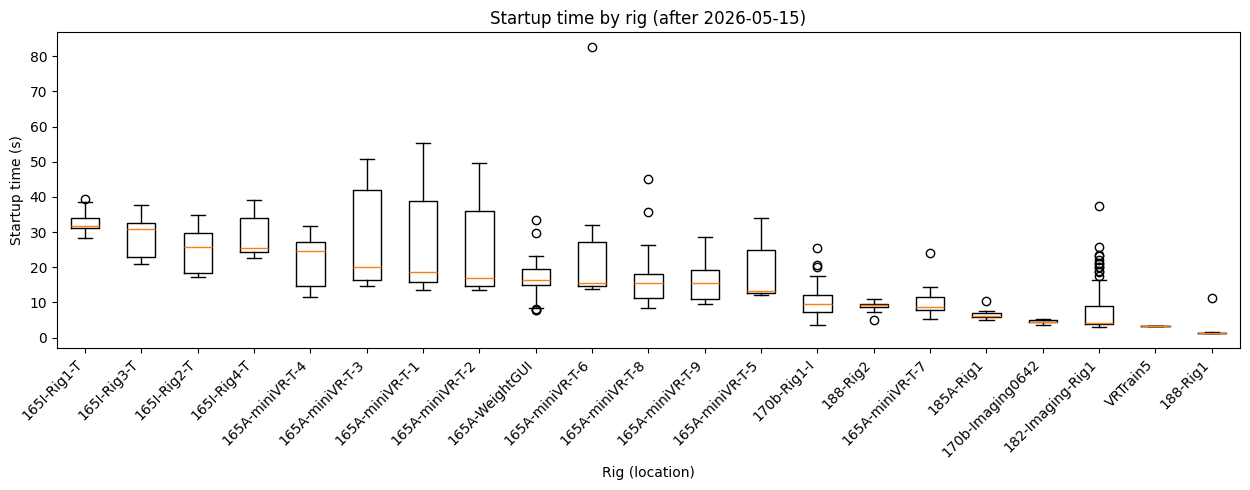

In [9]:
# === ALL RIGS ANALYSIS (after May 15th) ===
print("\n" + "="*70)
print("STARTUP TIME BY RIG (after 2026-05-15)")
print("="*70)

rig_stats_good = (
    df_good.groupby('location')['startup_time']
    .agg(median='median', mean='mean', std='std', count='count', p95=lambda x: x.quantile(0.95))
    .sort_values('median', ascending=False)
)
print(rig_stats_good.to_string())

fig, ax = plt.subplots(figsize=(max(10, len(rig_stats_good) * 0.6), 5))
order = rig_stats_good.index.tolist()
data_by_rig = [df_good[df_good['location'] == loc]['startup_time'].dropna() for loc in order]
ax.boxplot(data_by_rig, tick_labels=order, vert=True)
ax.set_xlabel('Rig (location)')
ax.set_ylabel('Startup time (s)')
ax.set_title('Startup time by rig (after 2026-05-15)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



STARTUP TYPE ANALYSIS (after 2026-05-15, all rigs)
                              median       mean       std  count        p95
startup_type                                                               
Rig Tester                  31.88365  32.800629  7.827085    252  48.530825
Training Flow GUI           21.68780  21.994108  8.048829    733  35.075900
No Schedule                  9.46736  10.598741  4.574051     52  15.342970
Not using New Training GUI   5.94023   8.390946  6.385273    253  21.374220


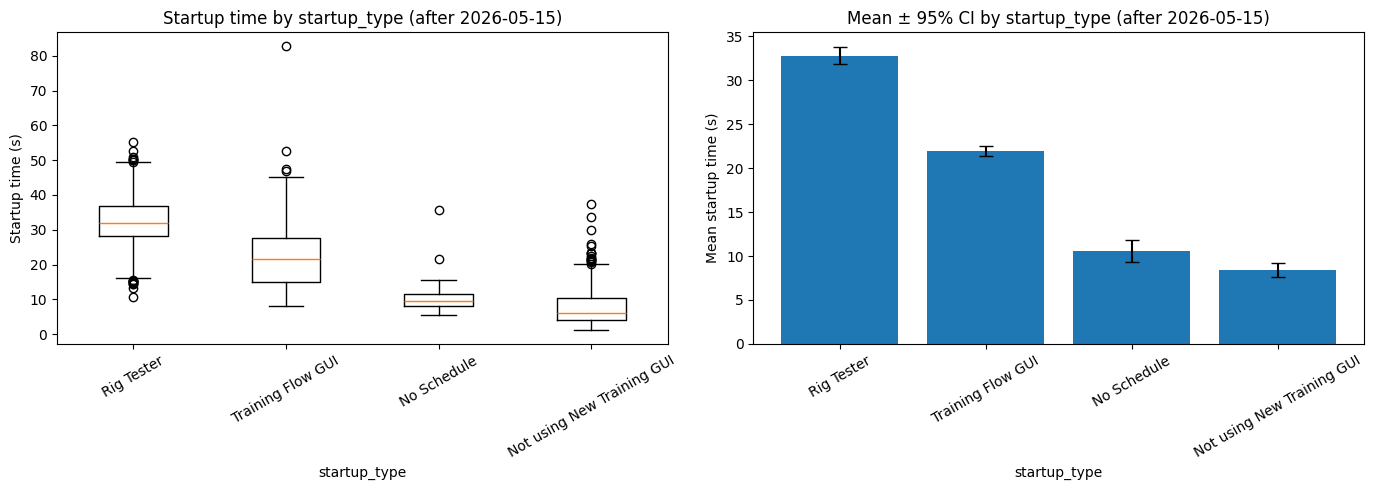

In [10]:
# === STARTUP TYPE ANALYSIS (after May 15th, all rigs) ===
print("\n" + "="*70)
print("STARTUP TYPE ANALYSIS (after 2026-05-15, all rigs)")
print("="*70)

type_stats_good = (
    df_good.groupby('startup_type')['startup_time']
    .agg(median='median', mean='mean', std='std', count='count', p95=lambda x: x.quantile(0.95))
    .sort_values('median', ascending=False)
)
print(type_stats_good.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_t = type_stats_good.index.tolist()
axes[0].boxplot(
    [df_good[df_good['startup_type'] == t]['startup_time'].dropna() for t in order_t],
    tick_labels=order_t,
)
axes[0].set_xlabel('startup_type')
axes[0].set_ylabel('Startup time (s)')
axes[0].set_title('Startup time by startup_type (after 2026-05-15)')
axes[0].tick_params(axis='x', rotation=30)

means_t = type_stats_good['mean']
sems_t = df_good.groupby('startup_type')['startup_time'].sem()
axes[1].bar(order_t, means_t[order_t], yerr=1.96 * sems_t[order_t], capsize=5)
axes[1].set_xlabel('startup_type')
axes[1].set_ylabel('Mean startup time (s)')
axes[1].set_title('Mean ± 95% CI by startup_type (after 2026-05-15)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()



NUM_SUBJ_SCHEDULED ANALYSIS (after 2026-05-15, all rigs)
Pearson r = 0.446

Startup time by num_subj_scheduled:
 num_subj_scheduled   median      mean  count
                  0  7.25109  8.767357    305
                  1 26.57510 26.253084     87
                  2 18.60670 24.473499    243
                  3 26.83010 25.851437    171
                  4 27.68410 25.598242    291
                  5 23.66360 22.210761    193


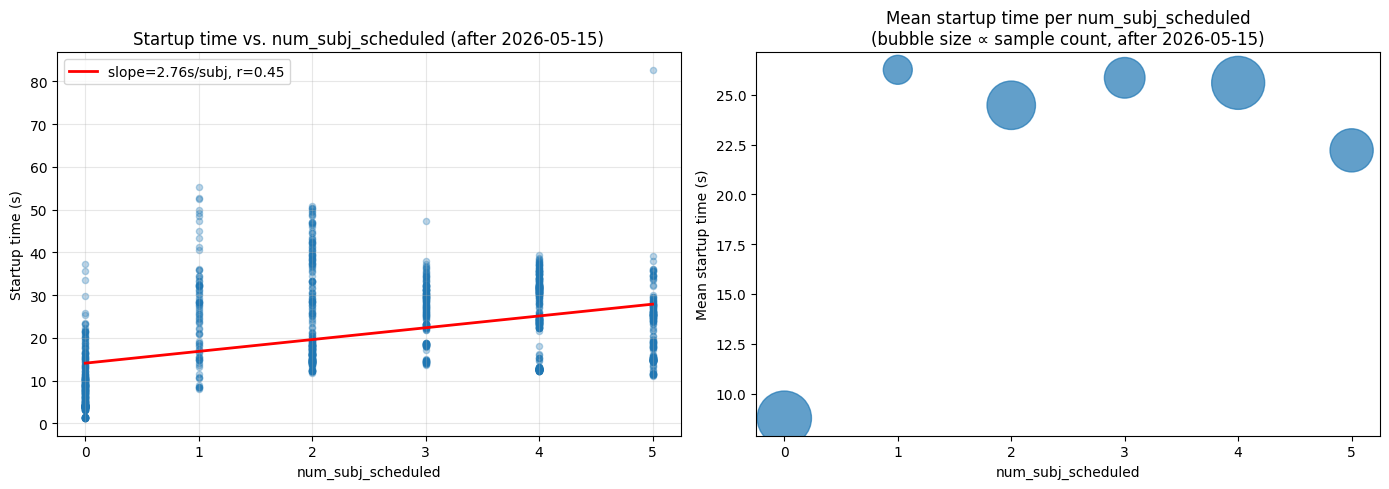

In [11]:
# === NUM_SUBJ_SCHEDULED ANALYSIS (after May 15th, all rigs) ===
print("\n" + "="*70)
print("NUM_SUBJ_SCHEDULED ANALYSIS (after 2026-05-15, all rigs)")
print("="*70)

corr_good = df_good[['num_subj_scheduled', 'startup_time']].corr().iloc[0, 1]
print(f"Pearson r = {corr_good:.3f}")

subj_stats_good = (
    df_good.groupby('num_subj_scheduled')['startup_time']
    .agg(median='median', mean='mean', count='count')
    .reset_index()
    .sort_values('num_subj_scheduled')
)
print("\nStartup time by num_subj_scheduled:")
print(subj_stats_good.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter with regression
x_good = df_good['num_subj_scheduled'].dropna()
y_good = df_good.loc[x_good.index, 'startup_time']
m_good, b_good = np.polyfit(x_good, y_good, 1)

axes[0].scatter(x_good, y_good, alpha=0.3, s=20)
xs_good = np.linspace(x_good.min(), x_good.max(), 100)
axes[0].plot(xs_good, m_good * xs_good + b_good, 'r-', linewidth=2, label=f'slope={m_good:.2f}s/subj, r={corr_good:.2f}')
axes[0].set_xlabel('num_subj_scheduled')
axes[0].set_ylabel('Startup time (s)')
axes[0].set_title('Startup time vs. num_subj_scheduled (after 2026-05-15)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bubble chart
axes[1].scatter(
    subj_stats_good['num_subj_scheduled'], subj_stats_good['mean'],
    s=subj_stats_good['count'] * 5, alpha=0.7,
)
axes[1].set_xlabel('num_subj_scheduled')
axes[1].set_ylabel('Mean startup time (s)')
axes[1].set_title('Mean startup time per num_subj_scheduled\n(bubble size ∝ sample count, after 2026-05-15)')

plt.tight_layout()
plt.show()


In [12]:
# === Which rigs take longest: filtered by startup_type ===
# Show all startup_types present in good data so we can confirm the labels
print("Startup types in good data:")
print(df_good['startup_type'].value_counts())


Startup types in good data:
startup_type
Training Flow GUI             733
Not using New Training GUI    253
Rig Tester                    252
No Schedule                    52
Name: count, dtype: int64


Rig Tester startup_type rows: 252
Training Flow GUI startup_type rows: 733

  Rig Tester: startup time by rig (sorted slowest → fastest)
                   median       mean       std  count
location                                             
165A-miniVR-T-3  44.76850  44.498565  4.200848     20
165A-miniVR-T-1  42.89705  42.953106  8.438373     18
165A-miniVR-T-2  40.88220  40.523205  7.153129     20
165I-Rig4-T      35.51260  34.192148  3.791273     27
165I-Rig1-T      33.37020  33.942662  2.363092     26
165I-Rig3-T      32.27780  32.342574  1.814083     27
165I-Rig2-T      30.75780  30.806544  2.194979     25
165A-miniVR-T-5  29.99040  28.656888  4.444015     25
165A-miniVR-T-6  27.48480  28.004684  1.739614     25
165A-miniVR-T-4  27.43940  26.699180  4.018570     25
165A-miniVR-T-9  23.85880  22.877250  6.239566      4
165A-miniVR-T-8  16.03070  18.194700  4.719025      5
165A-miniVR-T-7  14.30430  15.311140  5.084180      5


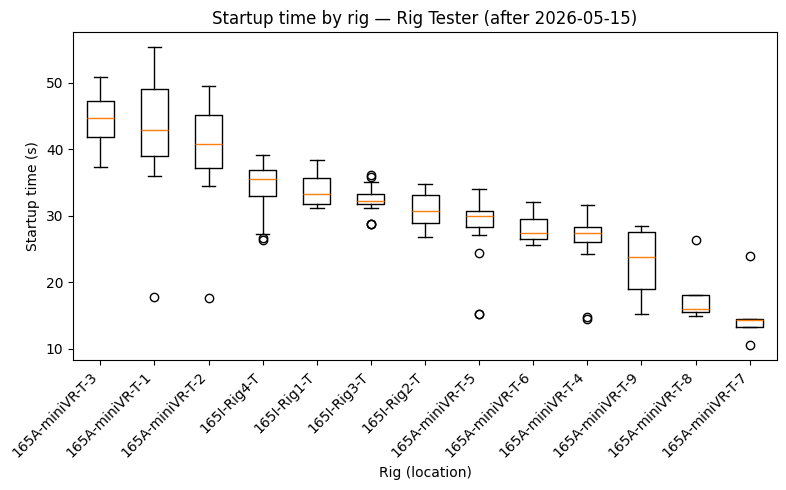


  Training Flow GUI: startup time by rig (sorted slowest → fastest)
                   median       mean       std  count
location                                             
165I-Rig1-T      31.57620  32.122519  2.394225     90
165I-Rig4-T      24.73840  26.649481  4.088648     97
165I-Rig3-T      23.37240  27.023923  5.213252     57
165A-miniVR-T-4  22.13885  19.208535  6.117544     40
165A-miniVR-T-9  18.89815  18.043569  3.212724     16
165I-Rig2-T      18.63550  21.989762  4.804092     58
165A-miniVR-T-3  18.61690  22.235145  9.406466     42
165A-miniVR-T-8  17.94240  18.790036  6.255641     22
165A-miniVR-T-1  17.79400  19.733315  8.228678     40
165A-miniVR-T-6  15.05070  19.343674  8.664433     97
165A-miniVR-T-2  14.94650  17.236554  6.360275     57
165A-miniVR-T-5  12.87550  16.091791  5.228811     97
165A-miniVR-T-7  11.48375  10.826655  1.665716     20


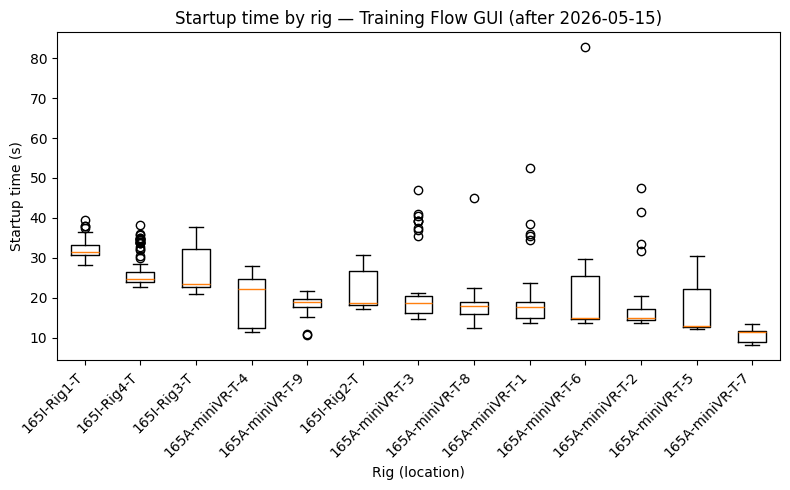

In [13]:
# === Rig Tester vs Training Flow GUI: which rigs take the longest? ===
# Adjust these strings to match the exact startup_type values printed above
df_rig_tester = df_good[df_good['startup_type'].str.contains('Rig Tester', case=False, na=False)]
df_training_gui = df_good[df_good['startup_type'].str.contains('Training Flow GUI', case=False, na=False)]

print(f"Rig Tester startup_type rows: {len(df_rig_tester)}")
print(f"Training Flow GUI startup_type rows: {len(df_training_gui)}")

# --- Which rigs take longest under each startup_type ---
for label, subset in [('Rig Tester', df_rig_tester), ('Training Flow GUI', df_training_gui)]:
    if len(subset) == 0:
        print(f"\n[{label}] No rows found — check startup_type label above")
        continue

    stats = (
        subset.groupby('location')['startup_time']
        .agg(median='median', mean='mean', std='std', count='count')
        .sort_values('median', ascending=False)
    )
    print(f"\n{'='*60}")
    print(f"  {label}: startup time by rig (sorted slowest → fastest)")
    print(f"{'='*60}")
    print(stats.to_string())

    fig, ax = plt.subplots(figsize=(max(8, len(stats) * 0.6), 5))
    locs = stats.index.tolist()
    ax.boxplot(
        [subset[subset['location'] == loc]['startup_time'].dropna() for loc in locs],
        tick_labels=locs,
    )
    ax.set_xlabel('Rig (location)')
    ax.set_ylabel('Startup time (s)')
    ax.set_title(f'Startup time by rig — {label} (after 2026-05-15)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()



  Rig Tester: effect of num_subj_scheduled  (r=-0.27, slope=-1.67s/subj)
 num_subj_scheduled   median      mean  count
                  1 31.59455 32.530182     34
                  2 38.35495 37.292775     72
                  3 31.19780 30.849330     47
                  4 31.90880 31.895062     63
                  5 27.85075 28.204033     36


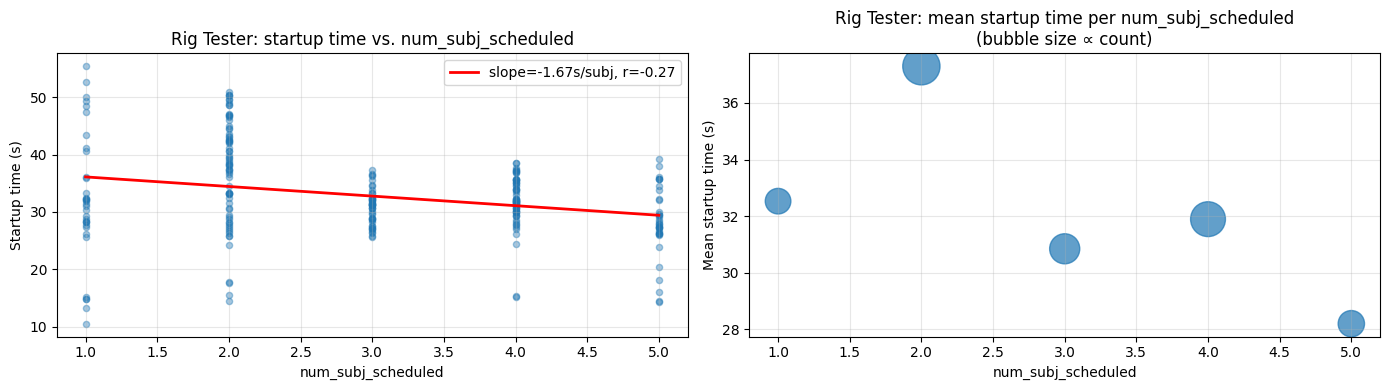


  Training Flow GUI: effect of num_subj_scheduled  (r=0.07, slope=0.47s/subj)
 num_subj_scheduled   median      mean  count
                  1 21.11200 22.226266     53
                  2 16.61140 19.075909    171
                  3 23.16735 23.957074    124
                  4 24.23300 23.858331    228
                  5 18.98010 20.836508    157


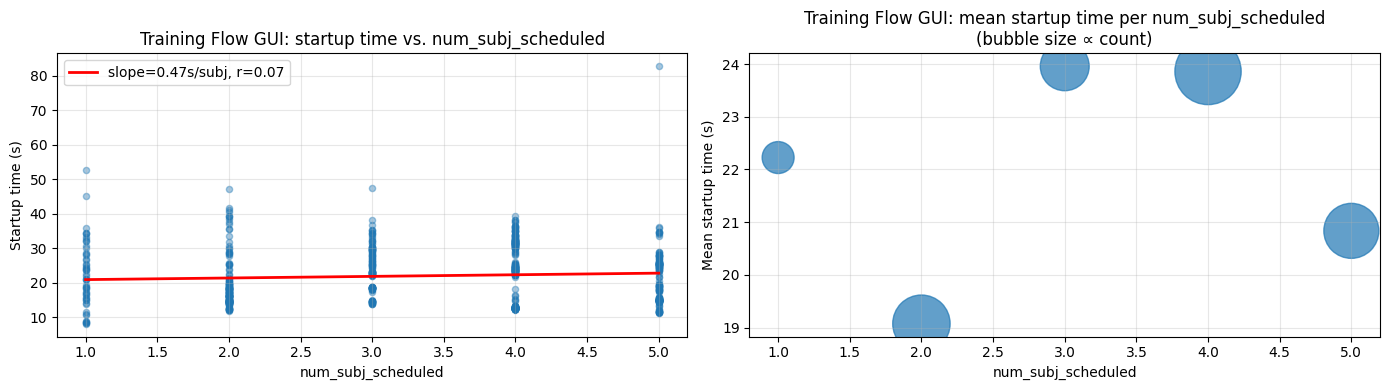

In [14]:
# === Does num_subj_scheduled matter within each startup_type? ===
for label, subset in [('Rig Tester', df_rig_tester), ('Training Flow GUI', df_training_gui)]:
    if len(subset) == 0:
        continue

    x = subset['num_subj_scheduled'].dropna()
    y = subset.loc[x.index, 'startup_time']

    if x.nunique() < 2:
        print(f"\n[{label}] Not enough variation in num_subj_scheduled to fit regression")
        continue

    corr = subset[['num_subj_scheduled', 'startup_time']].corr().iloc[0, 1]
    m, b = np.polyfit(x, y, 1)

    subj_stats = (
        subset.groupby('num_subj_scheduled')['startup_time']
        .agg(median='median', mean='mean', count='count')
        .reset_index()
        .sort_values('num_subj_scheduled')
    )

    print(f"\n{'='*60}")
    print(f"  {label}: effect of num_subj_scheduled  (r={corr:.2f}, slope={m:.2f}s/subj)")
    print(f"{'='*60}")
    print(subj_stats.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].scatter(x, y, alpha=0.4, s=20)
    xs = np.linspace(x.min(), x.max(), 100)
    axes[0].plot(xs, m * xs + b, 'r-', linewidth=2, label=f'slope={m:.2f}s/subj, r={corr:.2f}')
    axes[0].set_xlabel('num_subj_scheduled')
    axes[0].set_ylabel('Startup time (s)')
    axes[0].set_title(f'{label}: startup time vs. num_subj_scheduled')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].scatter(
        subj_stats['num_subj_scheduled'], subj_stats['mean'],
        s=subj_stats['count'] * 10, alpha=0.7,
    )
    axes[1].set_xlabel('num_subj_scheduled')
    axes[1].set_ylabel('Mean startup time (s)')
    axes[1].set_title(f'{label}: mean startup time per num_subj_scheduled\n(bubble size ∝ count)')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


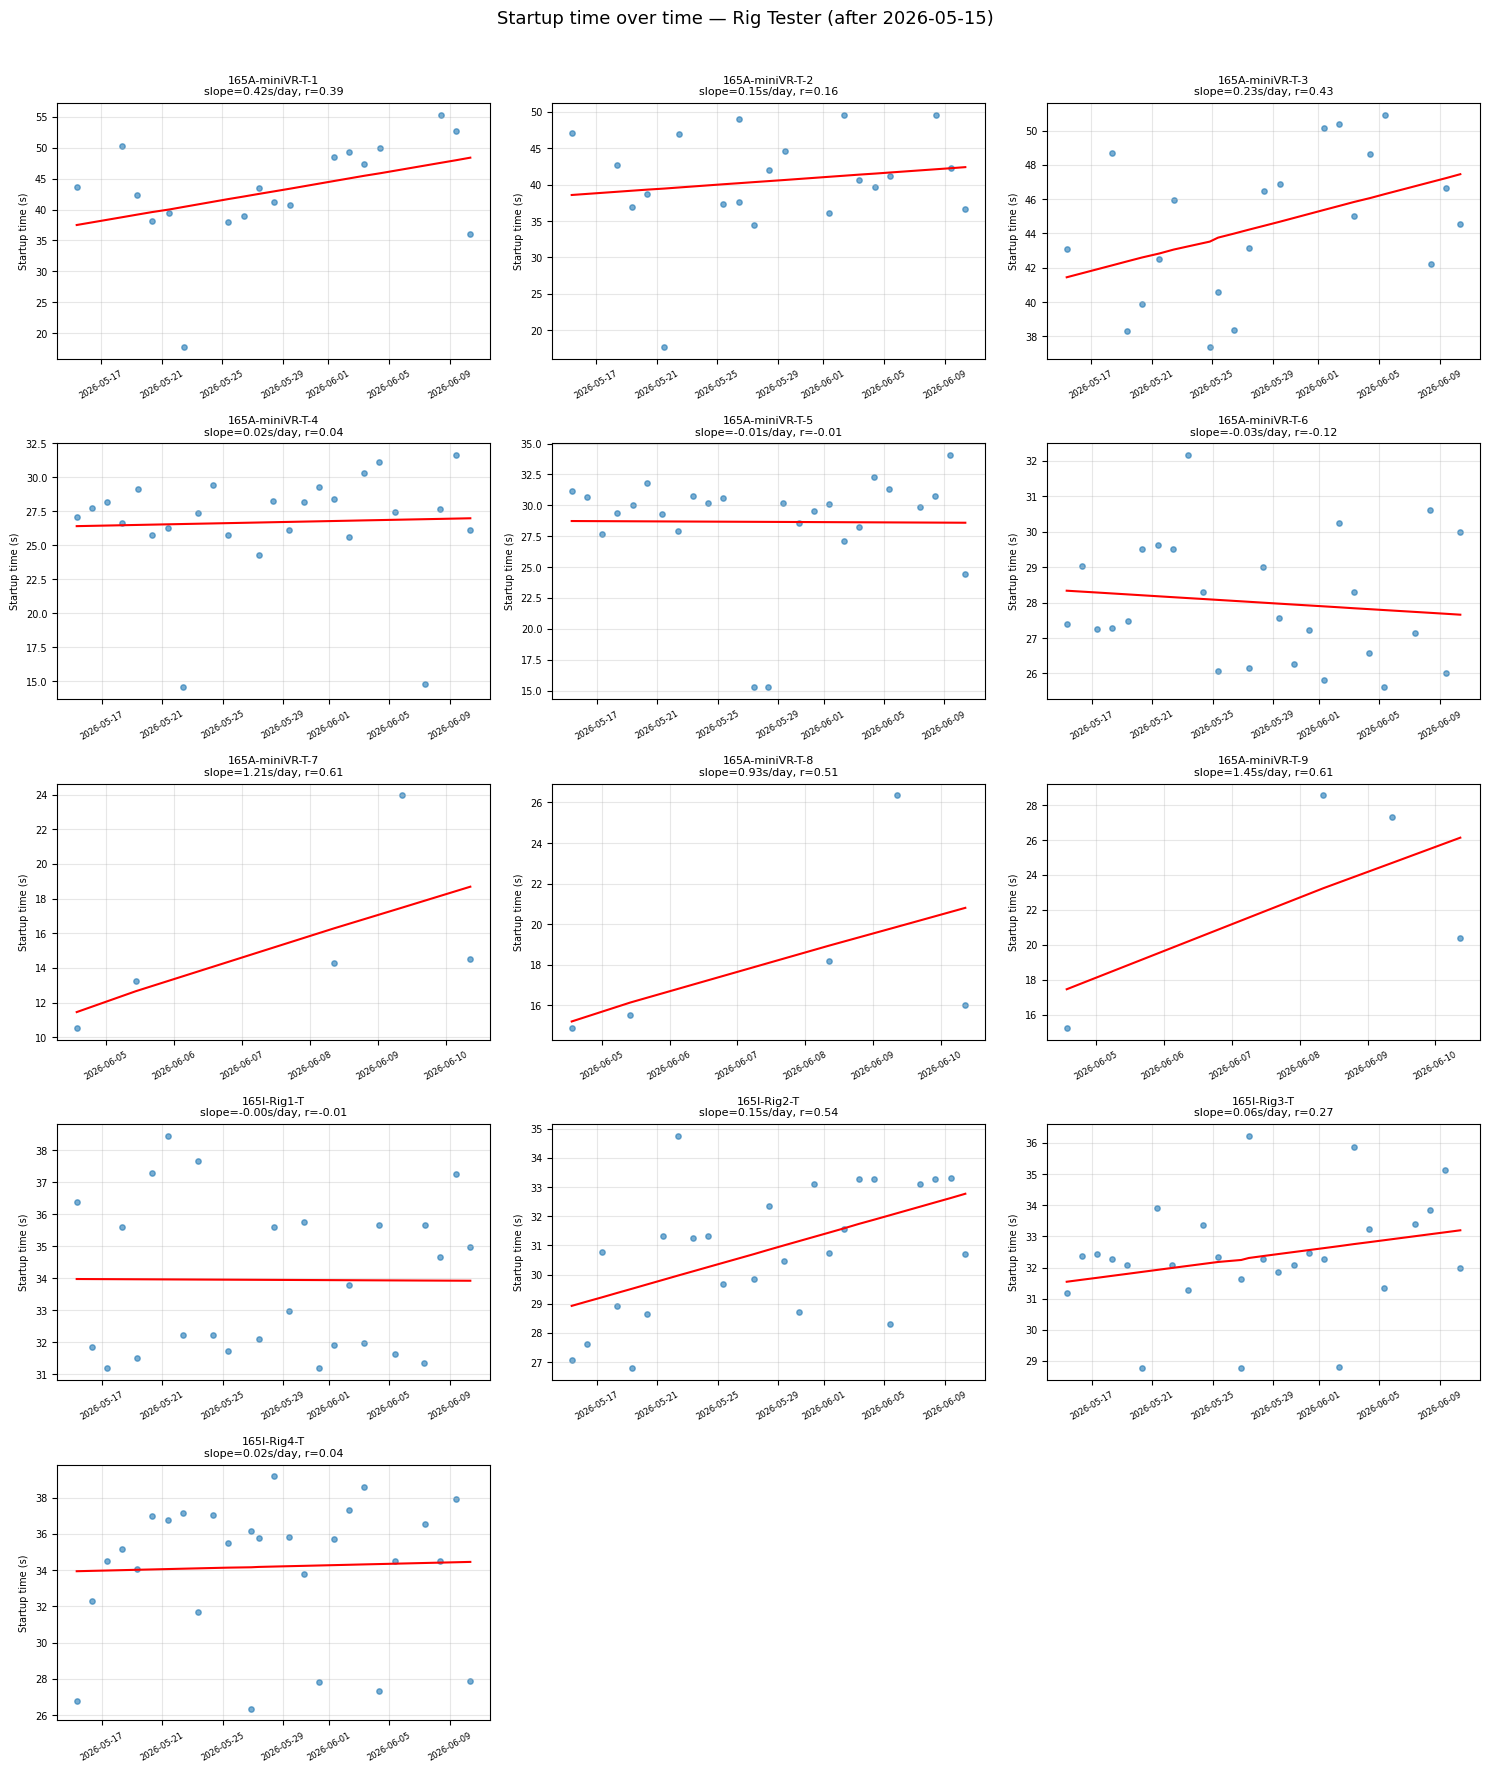


Rig Tester — trend summary (positive slope = getting slower over time):
       location  slope_s_per_day         r  n
165A-miniVR-T-9         1.447318  0.610040  4
165A-miniVR-T-7         1.205674  0.613827  5
165A-miniVR-T-8         0.932728  0.511611  5
165A-miniVR-T-1         0.419123  0.394785 18
165A-miniVR-T-3         0.231014  0.428426 20
    165I-Rig2-T         0.147793  0.541290 25
165A-miniVR-T-2         0.146914  0.159104 20
    165I-Rig3-T         0.063506  0.270864 27
165A-miniVR-T-4         0.022225  0.044461 25
    165I-Rig4-T         0.019784  0.040376 27
    165I-Rig1-T        -0.002071 -0.007127 26
165A-miniVR-T-5        -0.005297 -0.009581 25
165A-miniVR-T-6        -0.026035 -0.120314 25


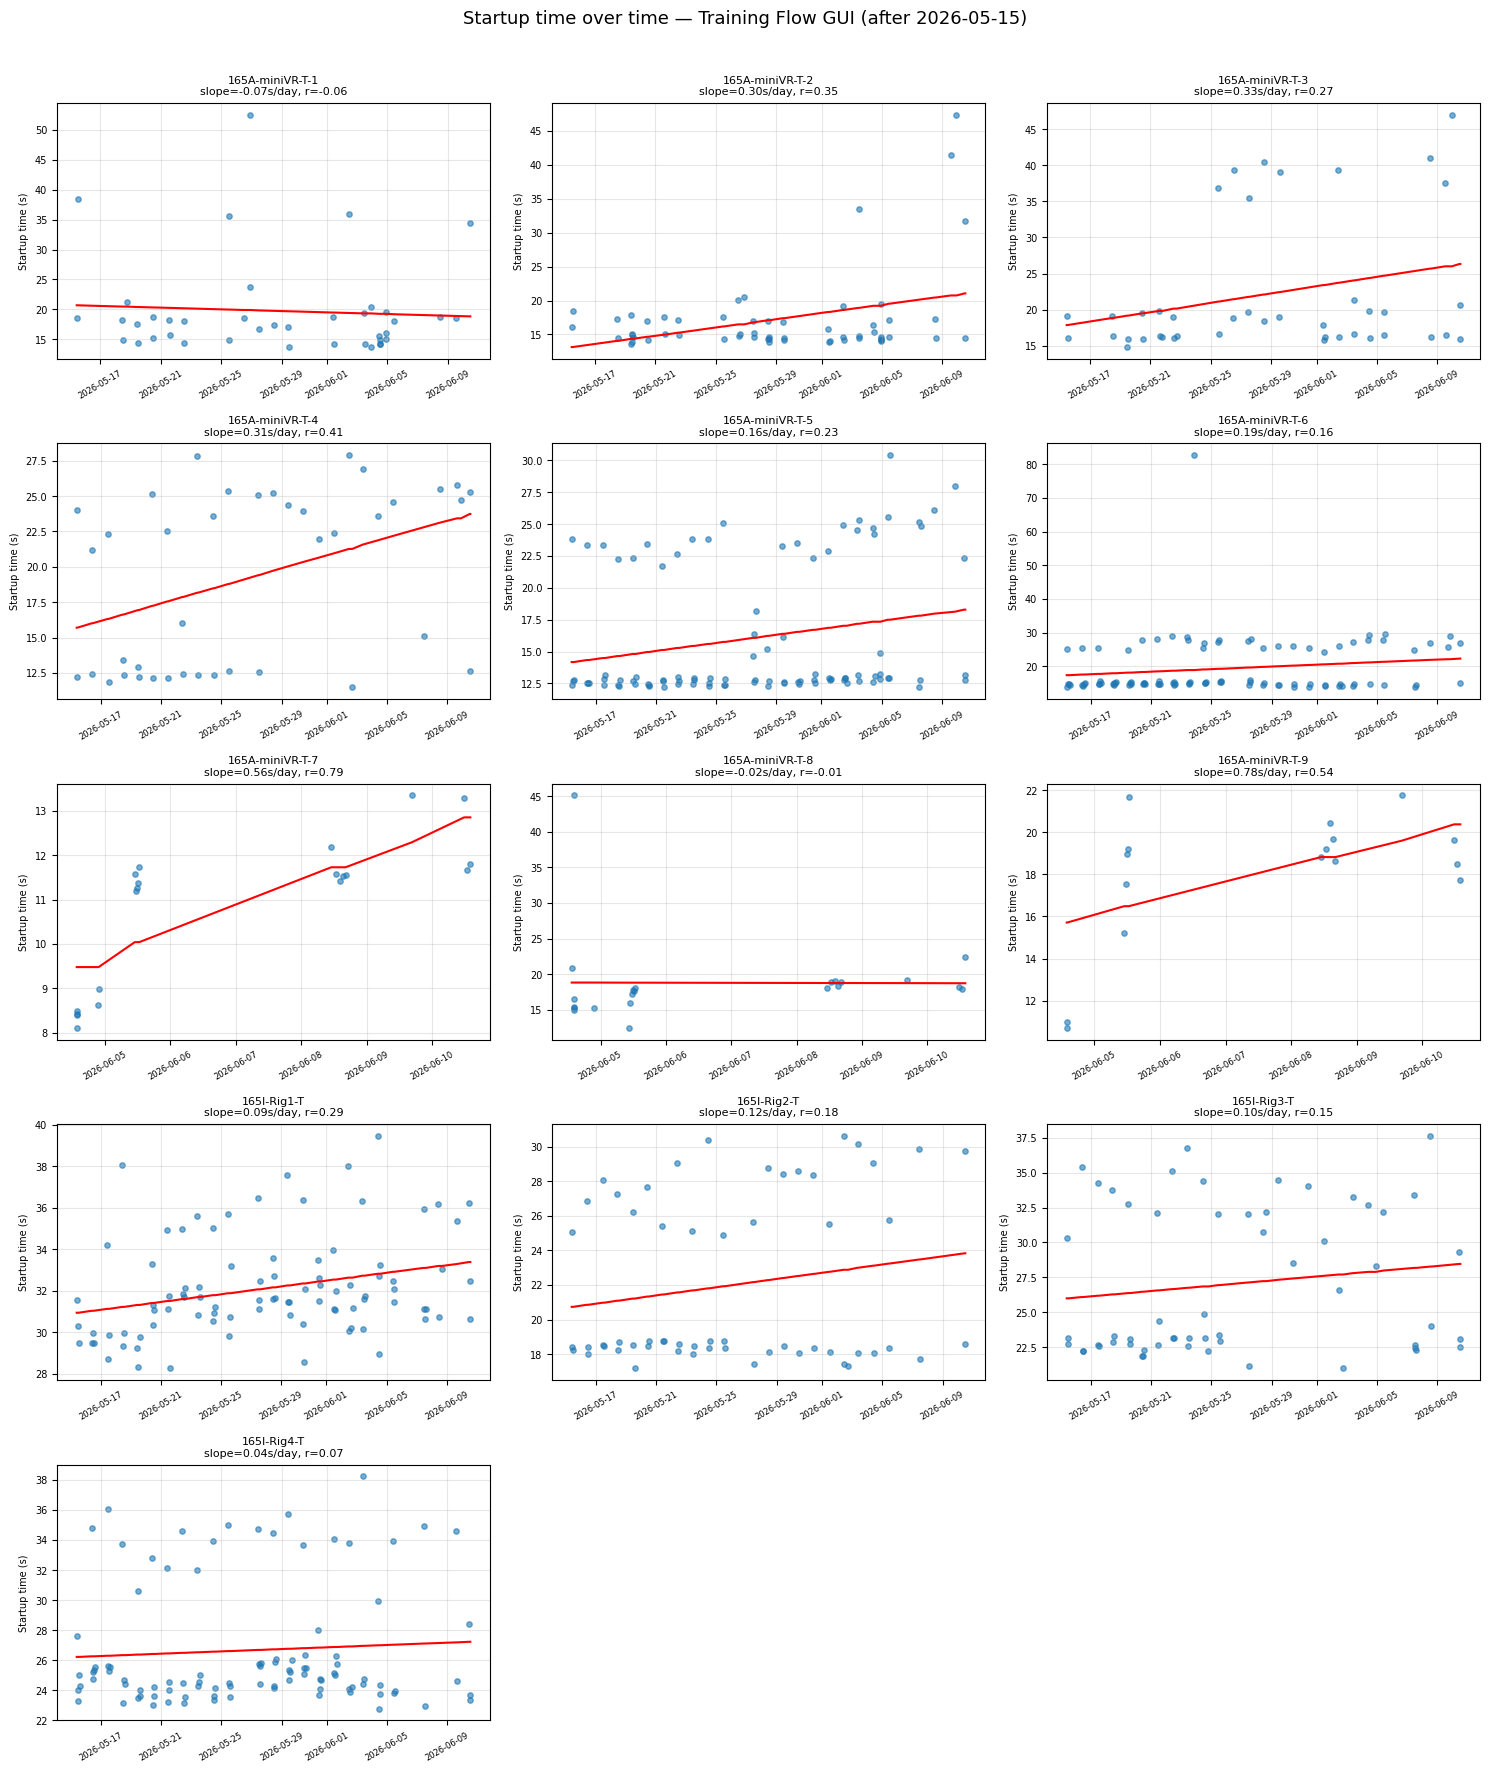


Training Flow GUI — trend summary (positive slope = getting slower over time):
       location  slope_s_per_day         r  n
165A-miniVR-T-9         0.778136  0.537963 16
165A-miniVR-T-7         0.562801  0.785912 20
165A-miniVR-T-3         0.325829  0.271154 42
165A-miniVR-T-4         0.309322  0.412615 40
165A-miniVR-T-2         0.304064  0.345220 57
165A-miniVR-T-6         0.189254  0.160140 97
165A-miniVR-T-5         0.158072  0.225607 97
    165I-Rig2-T         0.119057  0.181652 58
    165I-Rig3-T         0.095035  0.146771 57
    165I-Rig1-T         0.094000  0.288977 90
    165I-Rig4-T         0.038733  0.068738 97
165A-miniVR-T-8        -0.015792 -0.005774 22
165A-miniVR-T-1        -0.071379 -0.064746 40


In [15]:
# === Startup time as a function of calendar date, per rig, split by startup_type ===
df_good['date_ordinal'] = df_good['startup_datetime'].map(pd.Timestamp.toordinal)

for label, subset in [('Rig Tester', df_rig_tester), ('Training Flow GUI', df_training_gui)]:
    if len(subset) == 0:
        continue

    subset = subset.copy()
    subset['date_ordinal'] = subset['startup_datetime'].map(pd.Timestamp.toordinal)

    rigs = subset['location'].unique()
    n_rigs = len(rigs)
    cols = 3
    rows = int(np.ceil(n_rigs / cols))

    # --- Per-rig subplots with trend lines ---
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 3.5), squeeze=False)
    fig.suptitle(f'Startup time over time — {label} (after 2026-05-15)', fontsize=13, y=1.01)

    trend_rows = []
    for i, rig in enumerate(sorted(rigs)):
        ax = axes[i // cols][i % cols]
        grp = subset[subset['location'] == rig].dropna(subset=['startup_time', 'date_ordinal'])

        ax.scatter(grp['startup_datetime'], grp['startup_time'], s=15, alpha=0.6)

        if len(grp) >= 2:
            m, b = np.polyfit(grp['date_ordinal'], grp['startup_time'], 1)
            ax.plot(grp['startup_datetime'], m * grp['date_ordinal'] + b, 'r-', linewidth=1.5)
            corr = grp[['date_ordinal', 'startup_time']].corr().iloc[0, 1]
            trend_rows.append({'location': rig, 'slope_s_per_day': m, 'r': corr, 'n': len(grp)})
            ax.set_title(f'{rig}\nslope={m:.2f}s/day, r={corr:.2f}', fontsize=8)
        else:
            ax.set_title(f'{rig} (n={len(grp)})', fontsize=8)

        ax.set_ylabel('Startup time (s)', fontsize=7)
        ax.tick_params(axis='x', labelrotation=30, labelsize=6)
        ax.tick_params(axis='y', labelsize=7)
        ax.grid(True, alpha=0.3)

    # Hide unused subplots
    for j in range(i + 1, rows * cols):
        axes[j // cols][j % cols].set_visible(False)

    plt.tight_layout()
    plt.show()

    # --- Trend summary table ---
    if trend_rows:
        trend_df = (
            pd.DataFrame(trend_rows)
            .sort_values('slope_s_per_day', ascending=False)
            .reset_index(drop=True)
        )
        print(f"\n{label} — trend summary (positive slope = getting slower over time):")
        print(trend_df.to_string(index=False))
